# Model diagnosis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

###  Chargement des données

In [2]:
window_size = 10  # nombre d’événements à agréger
file_path = "var/new_table_2017-03-16.csv"

# === Fonction d’agrégation sur n événements ===
def aggregate_events(df, variables, window_size=10):
    df_copy = df.copy()

    if 'datetime' not in df_copy.columns:
        raise ValueError("La colonne 'datetime' est manquante.")

    df_copy['event_group'] = df_copy.reset_index().index // window_size
    datetime_col = df_copy.groupby('event_group')['datetime'].last()
    agg_data = df_copy.groupby('event_group')[variables].sum()
    agg_data['datetime'] = datetime_col.values
    agg_data.set_index('datetime', inplace=True)

    return agg_data

# === Chargement et préparation des données ===
df = pd.read_csv(file_path)

# Nettoyer les colonnes
df.columns = df.columns.str.strip()

# Vérifie la présence des colonnes 'date' et 'time'
if 'date' not in df.columns or 'time' not in df.columns:
    raise ValueError("Les colonnes 'date' et 'time' sont requises dans le CSV.")

# Création de datetime
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])



In [3]:
variables = ['V_lo_b', 'V_c_b', 'V_ex_b', 'V_lo_a', 'V_c_a', 'V_ex_a', 'mid_price']
df_model = aggregate_events(df, variables=variables, window_size=window_size)

### Estimation du modèle VAR

In [4]:
model = VAR(df_model)
results = model.fit(4)
results.summary()

c:\Users\remib\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 06, Jun, 2025
Time:                     11:50:22
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    65.4503
Nobs:                     24307.0    HQIC:                   65.4046
Log likelihood:      -1.03586e+06    FPE:                2.48501e+28
AIC:                      65.3827    Det(Omega_mle):     2.46435e+28
--------------------------------------------------------------------
Results for equation V_lo_b
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const             5226.088157      1243.414508            4.203           0.000
L1.V_lo_b            0.193349         0.008496           22.756           0.000
L1.V_c_b            -0.003911         0.008646           -0.452

### Vérification de la stabilité du modèle

In [5]:
print("Stabilité du modèle (doit être True) :", results.is_stable(verbose=True))

Eigenvalues of VAR(1) rep
0.9999716217171233
0.6826982885426646
0.6826982885426646
0.7088594132469881
0.6216540060133754
0.6216540060133754
0.596116029699251
0.5028591865193823
0.5028591865193823
0.4951349600698542
0.45648931418627087
0.45648931418627087
0.3548913106650087
0.3548913106650087
0.35592917824785275
0.35592917824785275
0.4293750935997422
0.4293750935997422
0.3295699548253569
0.3295699548253569
0.4388884635535724
0.4059065389661936
0.3490532156682813
0.20303296000277427
0.20303296000277427
0.1592492488269235
0.1592492488269235
0.0008727165950283477
Stabilité du modèle (doit être True) : True


### Analyse des résidus

In [6]:
residuals = results.resid
print("Moyenne des résidus (doit être proche de 0) :")
print(residuals.mean())

Moyenne des résidus (doit être proche de 0) :
V_lo_b       5.852228e-10
V_c_b        3.410602e-10
V_ex_b      -3.739978e-11
V_lo_a      -3.189760e-10
V_c_a       -2.772427e-10
V_ex_a       8.752245e-11
mid_price   -1.601891e-13
dtype: float64


### Test de Ljung-Box pour les résidus

In [7]:
for col in residuals.columns:
    lb_test = acorr_ljungbox(residuals[col], lags=[10], return_df=True)
    print(f"\n{col}:")
    print(lb_test)


V_lo_b:
     lb_stat  lb_pvalue
10  4.417371   0.926561

V_c_b:
     lb_stat  lb_pvalue
10  8.637413   0.566825

V_ex_b:
      lb_stat  lb_pvalue
10  12.518064   0.251879

V_lo_a:
      lb_stat  lb_pvalue
10  11.733168   0.303312

V_c_a:
     lb_stat  lb_pvalue
10  3.575204   0.964483

V_ex_a:
      lb_stat  lb_pvalue
10  35.522995   0.000102

mid_price:
     lb_stat  lb_pvalue
10  0.006174        1.0


### Tracés ACF / PACF des résidus

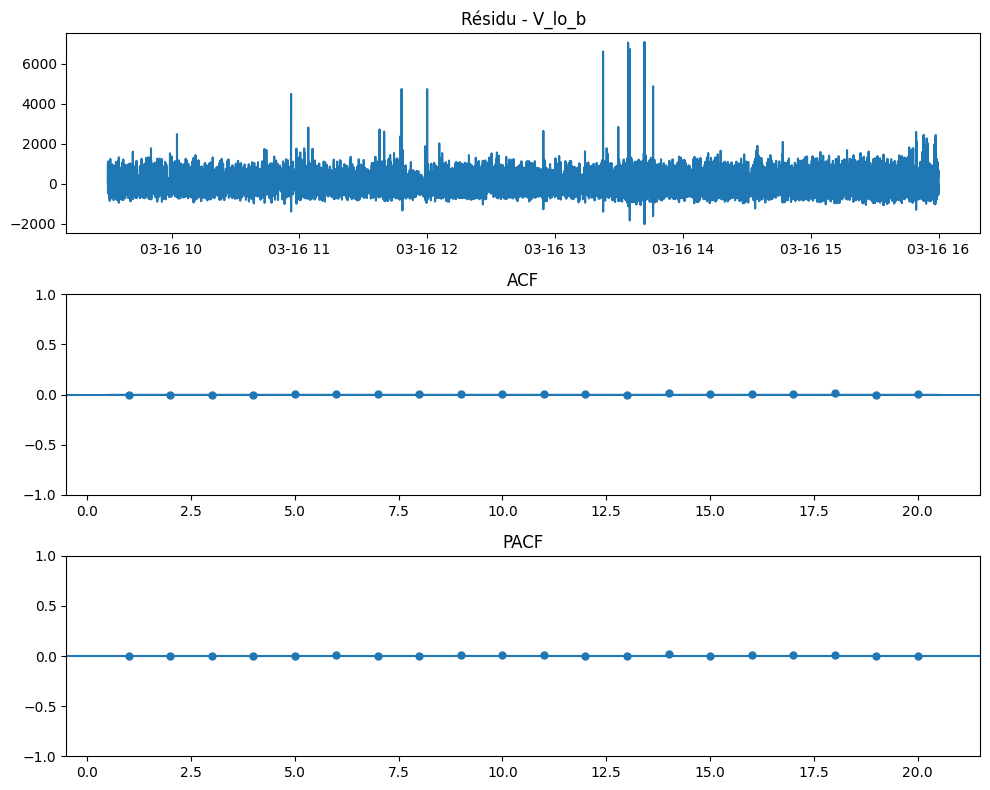

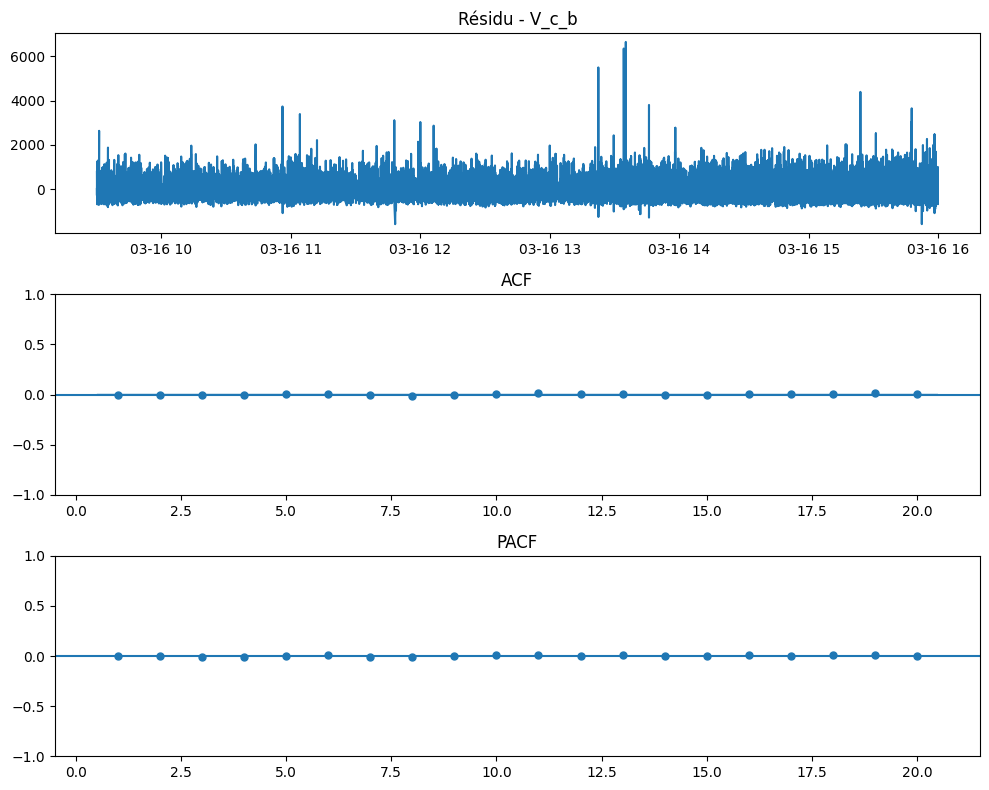

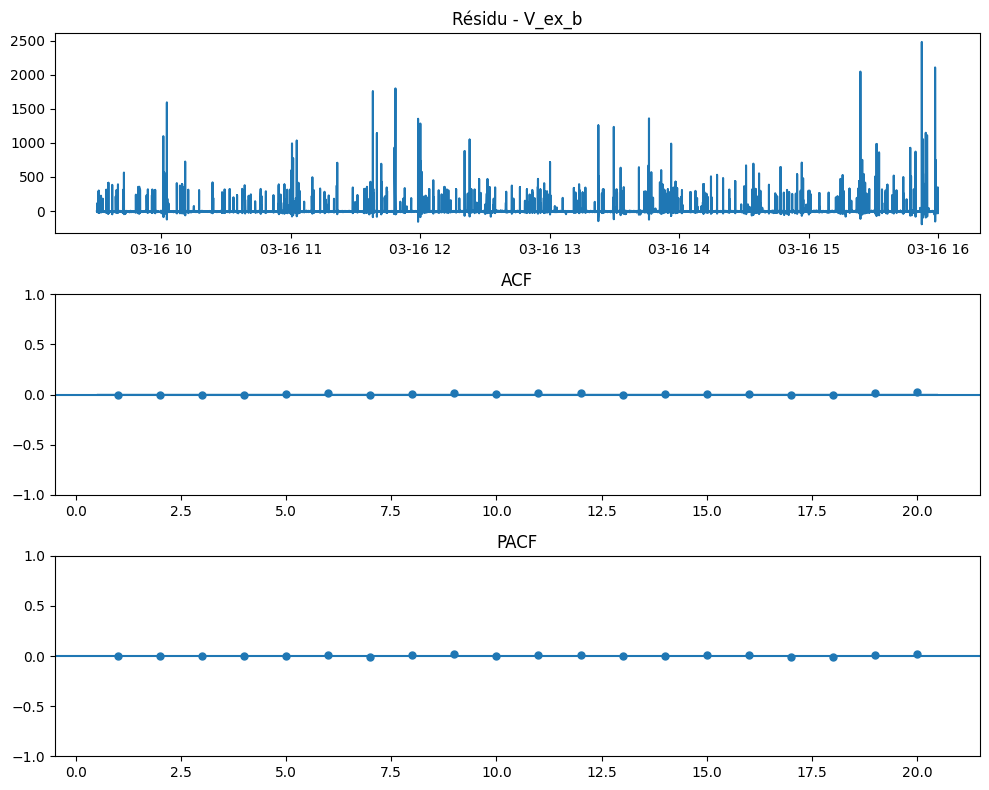

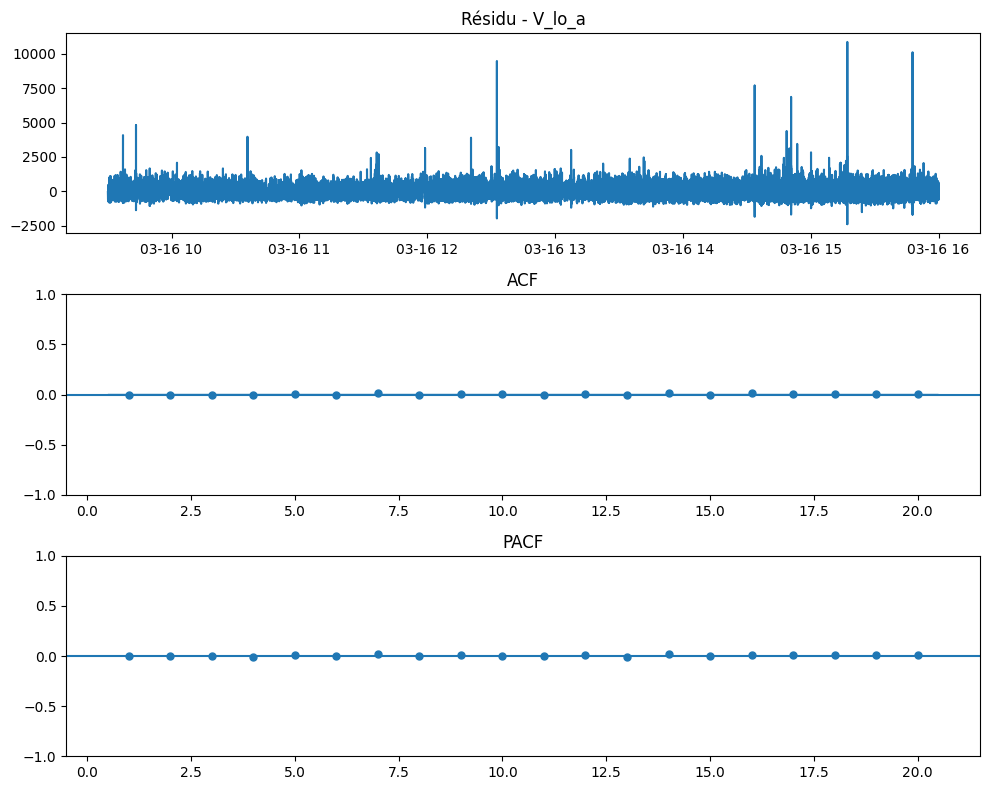

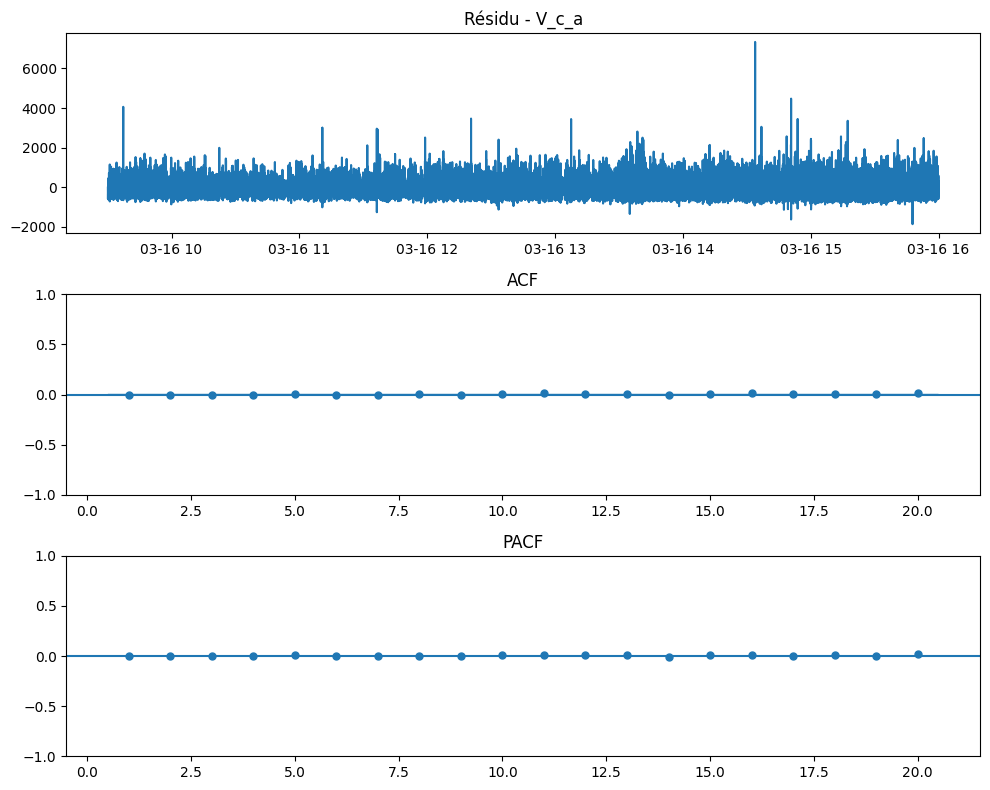

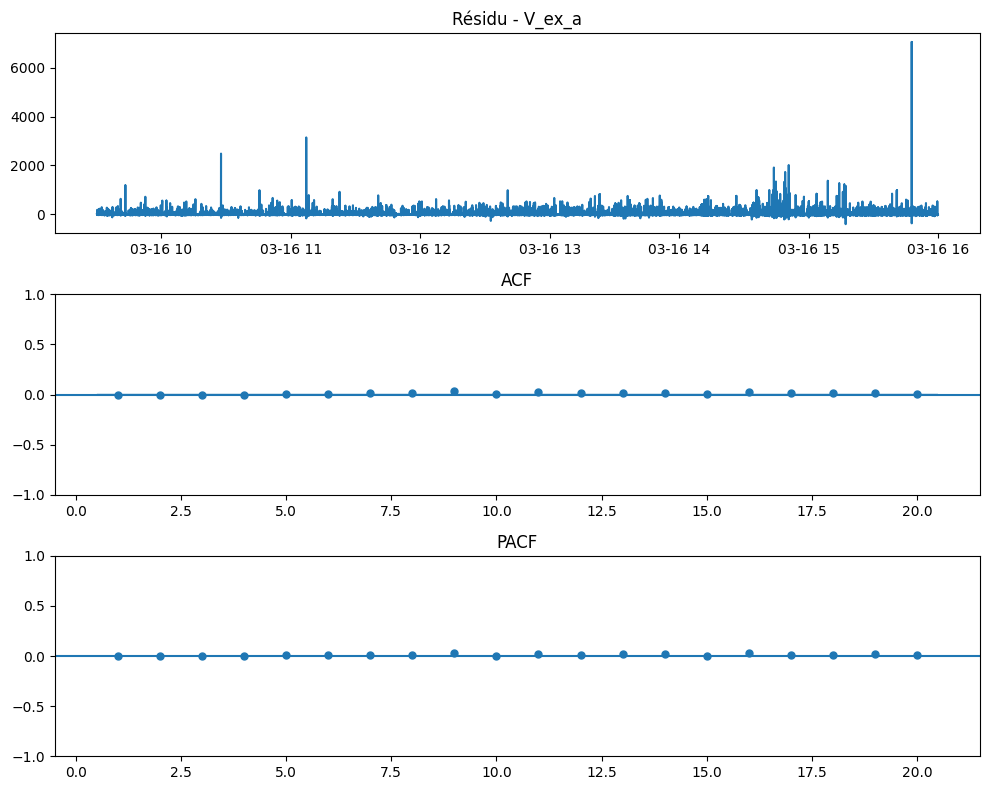

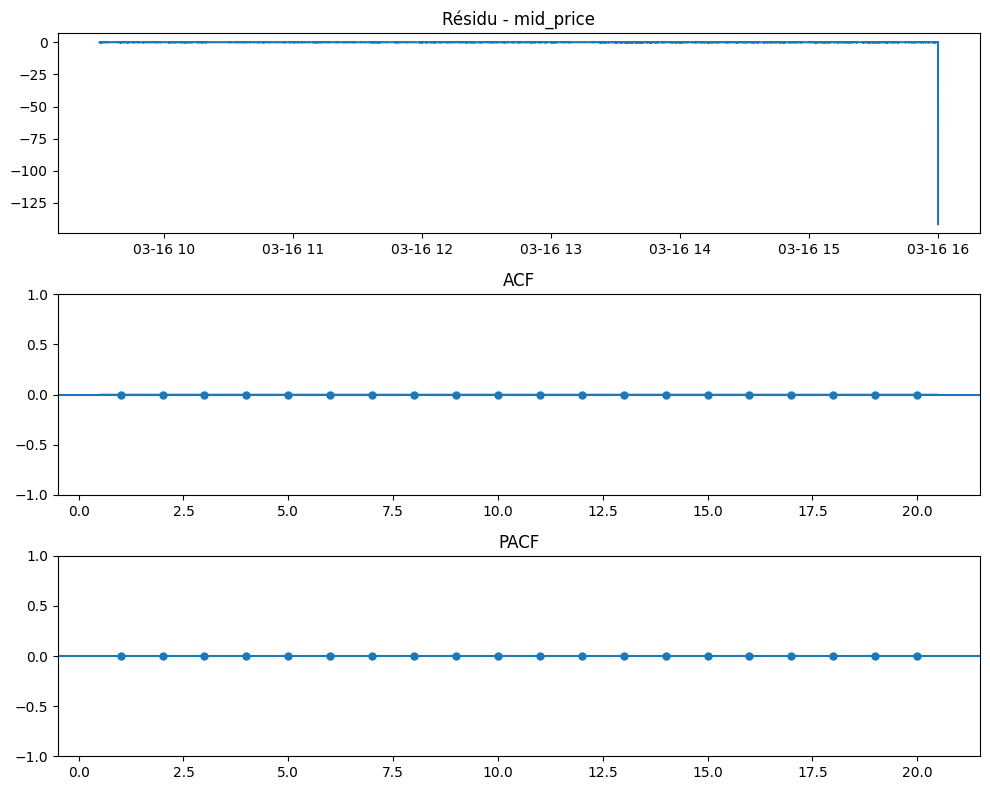

In [8]:
for col in residuals.columns:
    fig, axs = plt.subplots(3, 1, figsize=(10, 8))
    axs[0].plot(residuals[col])
    axs[0].set_title(f"Résidu - {col}")

    plot_acf(residuals[col], ax=axs[1], lags=20, alpha = 0.05, zero=False)
    axs[1].set_title("ACF")

    plot_pacf(residuals[col], ax=axs[2], lags=20, alpha = 0.05, zero=False)
    axs[2].set_title("PACF")

    plt.tight_layout()
    plt.show()

### Fonctions de réponse impulsionnelle

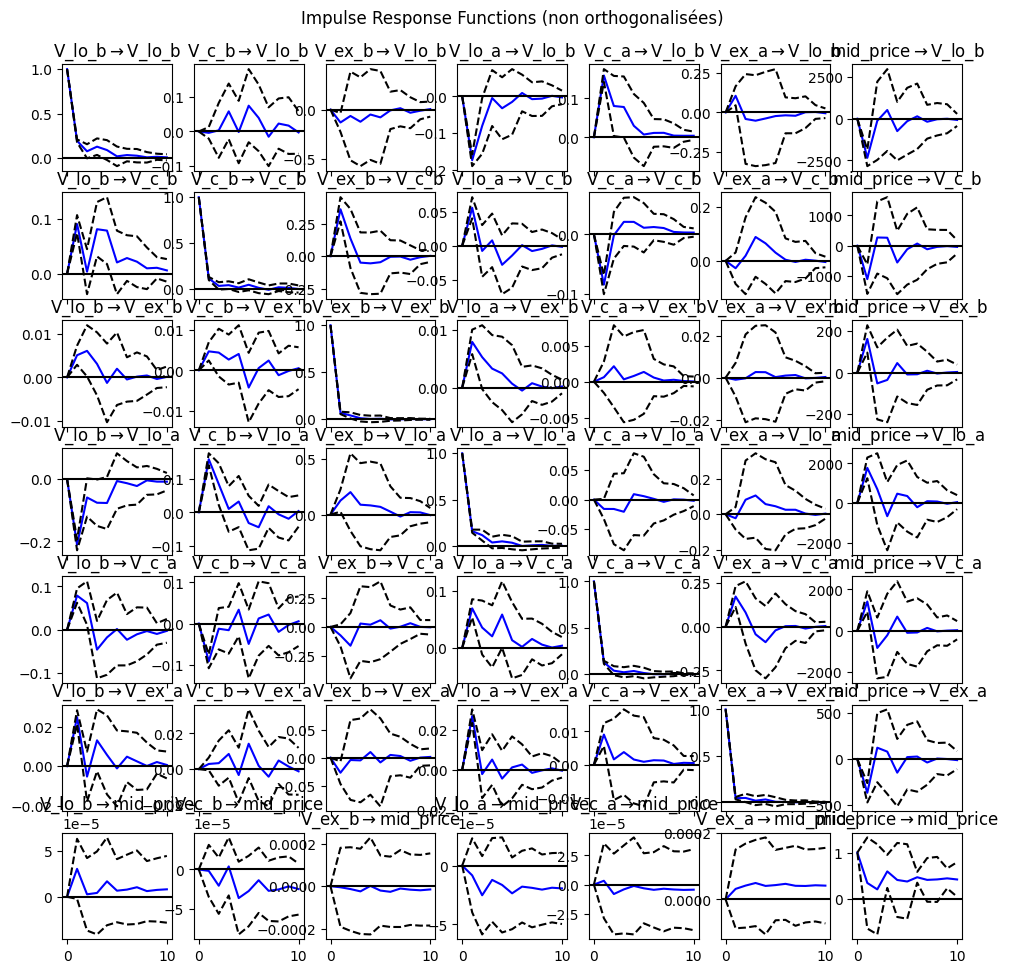

In [9]:
irf = results.irf(10)
fig = irf.plot(orth=False)
plt.suptitle("Impulse Response Functions (non orthogonalisées)")
plt.show()